# Метод k ближайших соседей (KNN)

Лабораторная работа №3.

**Задача:** бинарная классификация — предсказать, выжил ли пассажир «Титаника» (`survived`).

**Датасет:** `seaborn.load_dataset('titanic')` — категориальные признаки и пропуски, что позволяет показать предобработку перед обучением KNN.


## 1) Описание набора данных

- Документация Seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
- Исходное описание: https://www.kaggle.com/c/titanic/data

Набор содержит **891** запись. Целевая переменная — `survived` (0/1).

Используемые признаки после отбора:

| Тип | Признаки |
|-----|----------|
| Числовые | `pclass`, `age`, `sibsp`, `parch`, `fare`, `alone` |
| Категориальные | `sex`, `embarked` |

Исключаем дублирующие/утекающие столбцы (`alive`, `class`, `who`, `deck`, …).


## Импорт библиотек


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    StratifiedKFold,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

%matplotlib inline
sns.set(style="ticks")


Matplotlib is building the font cache; this may take a moment.


## Загрузка и первичный осмотр


In [2]:
df = sns.load_dataset("titanic")
print("Размер:", df.shape)
display(df.head())
print("\nПропуски:")
display(df.isna().sum().sort_values(ascending=False).to_frame("count"))


Размер: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Пропуски:


,count
deck,688
age,177
embarked,2
embark_town,2
survived,0
pclass,0
sex,0
sibsp,0
parch,0
fare,0


## Предобработка данных

1. Удаляем столбцы с утечкой целевой информации и избыточные категории.
2. Заполняем пропуски: медиана для числовых, мода для категориальных.
3. Кодируем категории через `OneHotEncoder`.
4. Масштабируем числовые признаки (`StandardScaler`) — для KNN это обязательно.


In [3]:
TARGET = "survived"
DROP_COLS = [
    "alive",
    "class",
    "who",
    "adult_male",
    "deck",
    "embark_town",
]

NUMERIC_FEATURES = ["pclass", "age", "sibsp", "parch", "fare", "alone"]
CATEGORICAL_FEATURES = ["sex", "embarked"]

data = df.drop(columns=DROP_COLS, errors="ignore")
y = data[TARGET]
X = data.drop(columns=[TARGET])

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

def make_knn_pipeline(n_neighbors: int) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("knn", KNeighborsClassifier(n_neighbors=n_neighbors)),
        ]
    )

print("Признаки X:", list(X.columns))
print("Распределение классов:")
print(y.value_counts(normalize=True).round(3))


Признаки X: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
Распределение классов:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## Разделение на обучающую и тестовую выборки


In [4]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Train: 712, Test: 179


## Базовая модель KNN (фиксированный гиперпараметр K)

Обучаем KNN с **K = 7** (произвольно заданное значение) и оцениваем качество на тестовой выборке.


In [5]:
K_INIT = 7

baseline_model = make_knn_pipeline(n_neighbors=K_INIT)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)


def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


baseline_metrics = evaluate_model(y_test, y_pred_baseline, f"KNN (K={K_INIT})")
pd.Series(baseline_metrics)


model        KNN (K=7)
accuracy      0.793296
precision         0.75
recall        0.695652
f1            0.721805
dtype: object

              precision    recall  f1-score   support

not survived       0.82      0.85      0.84       110
    survived       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



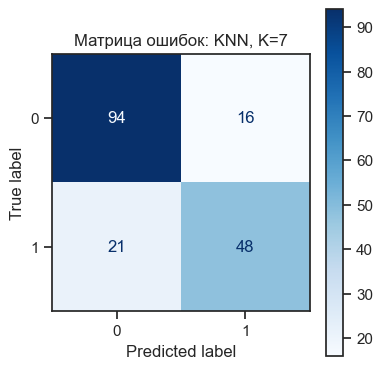

In [6]:
print(classification_report(y_test, y_pred_baseline, target_names=["not survived", "survived"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_baseline)).plot(ax=ax, cmap="Blues")
ax.set_title(f"Матрица ошибок: KNN, K={K_INIT}")
plt.tight_layout()
plt.show()


## Подбор гиперпараметров

Используем **две стратегии кросс-валидации**:

1. `StratifiedKFold` — сохраняет долю классов в каждом фолде (для `GridSearchCV`).
2. `KFold` — обычное K-блочное разбиение без стратификации (для `RandomizedSearchCV`).

Метрика для подбора на кросс-валидации: **F1** (подходит для несбалансированной бинарной классификации).


In [7]:
param_grid = {
    "knn__n_neighbors": list(range(3, 31, 2)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=make_knn_pipeline(n_neighbors=5),
    param_grid=param_grid,
    cv=cv_stratified,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры (GridSearchCV):")
print(grid_search.best_params_)
print(f"Лучший средний F1 на CV: {grid_search.best_score_:.4f}")


Лучшие параметры (GridSearchCV):
{'knn__metric': 'euclidean', 'knn__n_neighbors': 25, 'knn__weights': 'uniform'}
Лучший средний F1 на CV: 0.7418


In [8]:
from scipy.stats import randint

param_distributions = {
    "knn__n_neighbors": randint(1, 40),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"],
    "knn__p": [1, 2],
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=make_knn_pipeline(n_neighbors=5),
    param_distributions=param_distributions,
    n_iter=40,
    cv=cv_kfold,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

random_search.fit(X_train, y_train)

print("Лучшие параметры (RandomizedSearchCV):")
print(random_search.best_params_)
print(f"Лучший средний F1 на CV: {random_search.best_score_:.4f}")


Лучшие параметры (RandomizedSearchCV):
{'knn__metric': 'euclidean', 'knn__n_neighbors': 23, 'knn__p': 1, 'knn__weights': 'uniform'}
Лучший средний F1 на CV: 0.7542


## Оценка оптимальных моделей на тестовой выборке


In [9]:
y_pred_grid = grid_search.predict(X_test)
y_pred_random = random_search.predict(X_test)

grid_metrics = evaluate_model(y_test, y_pred_grid, "KNN (GridSearchCV)")
random_metrics = evaluate_model(y_test, y_pred_random, "KNN (RandomizedSearchCV)")

comparison = pd.DataFrame(
    [baseline_metrics, grid_metrics, random_metrics]
).set_index("model")

comparison_rounded = comparison.round(4)
display(comparison_rounded)


,accuracy,precision,recall,f1
model,,,,
KNN (K=7),0.7933,0.7500,0.6957,0.7218
KNN (GridSearchCV),0.7709,0.7333,0.6377,0.6822
KNN (RandomizedSearchCV),0.7821,0.7500,0.6522,0.6977


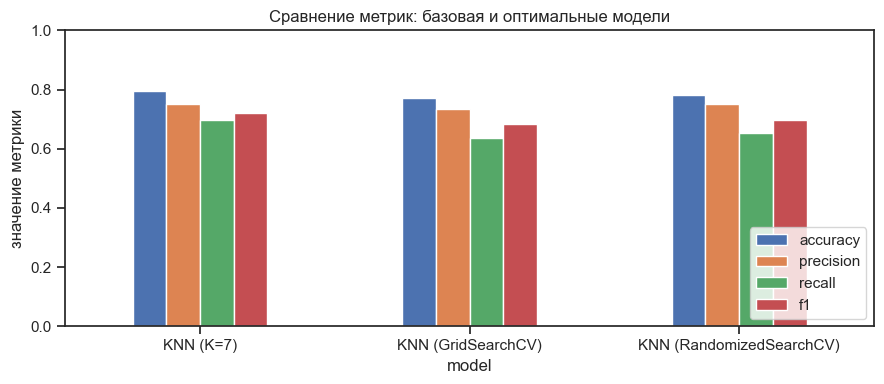

In [10]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
ax = comparison_rounded[metrics_to_plot].plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_ylabel("значение метрики")
ax.set_title("Сравнение метрик: базовая и оптимальные модели")
ax.legend(loc="lower right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Выводы


In [11]:
best_test = comparison_rounded["f1"].idxmax()
baseline_f1 = comparison_rounded.loc[f"KNN (K={K_INIT})", "f1"]
best_f1 = comparison_rounded.loc[best_test, "f1"]

print(
    f"Базовая модель (K={K_INIT}): F1 на тесте = {baseline_f1:.4f}\n"
    f"Лучшая по F1 на тесте: {best_test}, F1 = {best_f1:.4f}\n"
    f"Прирост F1 после подбора гиперпараметров: {best_f1 - baseline_f1:+.4f}"
)

print("\nПараметры лучшей модели по GridSearchCV:")
print(grid_search.best_params_)
print("\nПараметры лучшей модели по RandomizedSearchCV:")
print(random_search.best_params_)


Базовая модель (K=7): F1 на тесте = 0.7218
Лучшая по F1 на тесте: KNN (K=7), F1 = 0.7218
Прирост F1 после подбора гиперпараметров: +0.0000

Параметры лучшей модели по GridSearchCV:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 25, 'knn__weights': 'uniform'}

Параметры лучшей модели по RandomizedSearchCV:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 23, 'knn__p': 1, 'knn__weights': 'uniform'}
